In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
433,2957-LOLHO,Male,0,No,No,12,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),45.40,518.9,Yes
2285,4307-KTUMW,Male,0,Yes,No,53,Yes,Yes,Fiber optic,Yes,...,Yes,No,No,Yes,Month-to-month,No,Electronic check,93.90,5029.2,Yes
3098,4248-HCETZ,Male,1,Yes,No,30,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Mailed check,79.65,2365.15,Yes
4960,7480-QNVZJ,Male,1,No,No,50,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.70,4816.7,Yes
616,6464-KEXXH,Male,0,No,No,8,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),25.25,186.3,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(7043, 21)

In [8]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


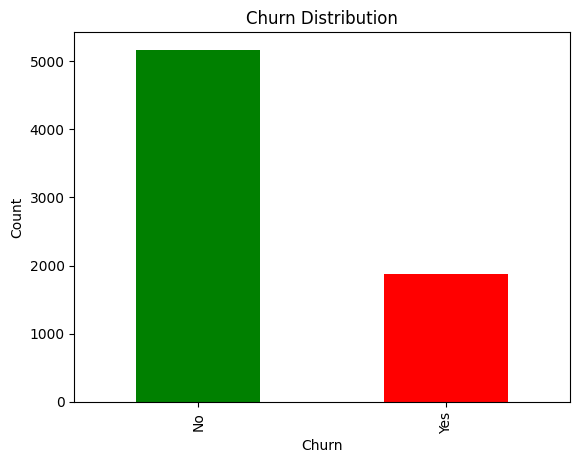

In [9]:
df['Churn'].value_counts()
print(df['Churn'].value_counts(normalize=True)*100)

# plot it!
df['Churn'].value_counts().plot(kind='bar',color=['green','red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<function matplotlib.pyplot.show(close=None, block=None)>

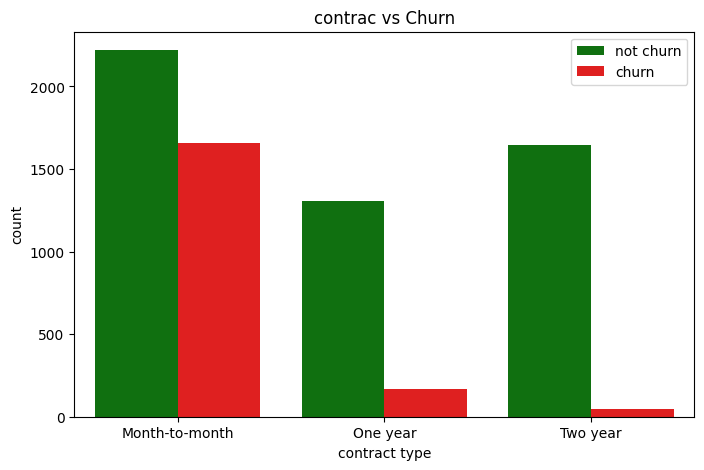

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract",hue="Churn",data=df,palette=["green","red"])
plt.title("contrac vs Churn")
plt.xlabel("contract type")
plt.ylabel("count")
plt.legend(["not churn","churn"])
plt.show

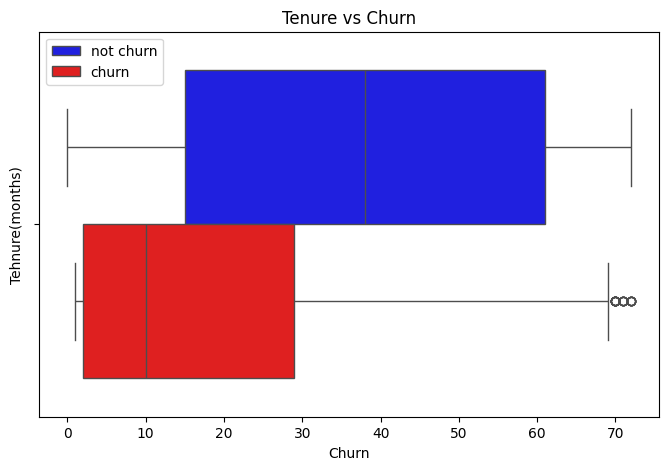

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="tenure",hue="Churn",data=df,palette=["blue","red"])
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tehnure(months)")
plt.legend(["not churn","churn"])
plt.show()

In [13]:
num=df.select_dtypes(include=["int64","float64"])
num

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65
...,...,...,...,...
7038,0,24,84.80,1990.50
7039,0,72,103.20,7362.90
7040,0,11,29.60,346.45
7041,1,4,74.40,306.60


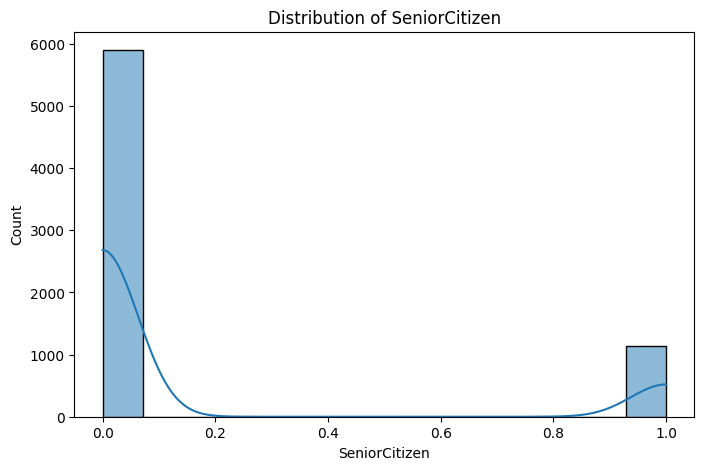

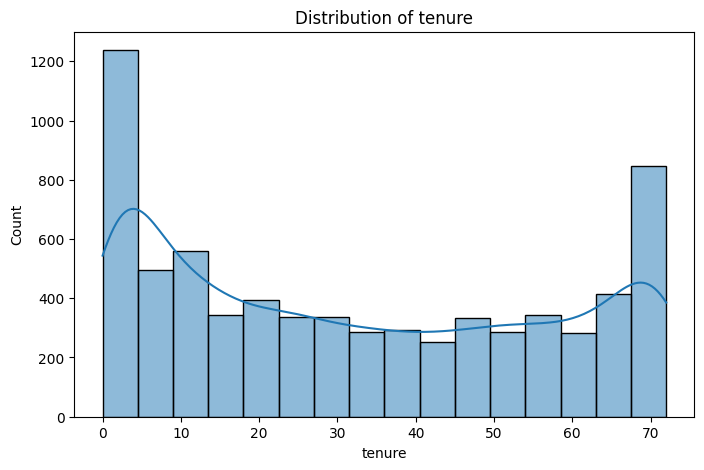

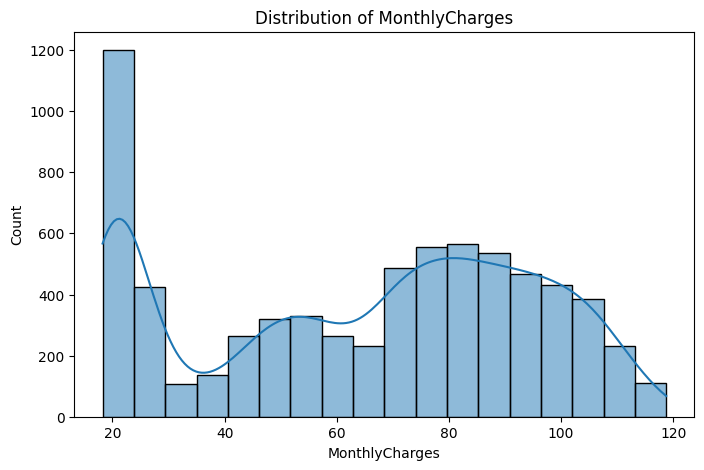

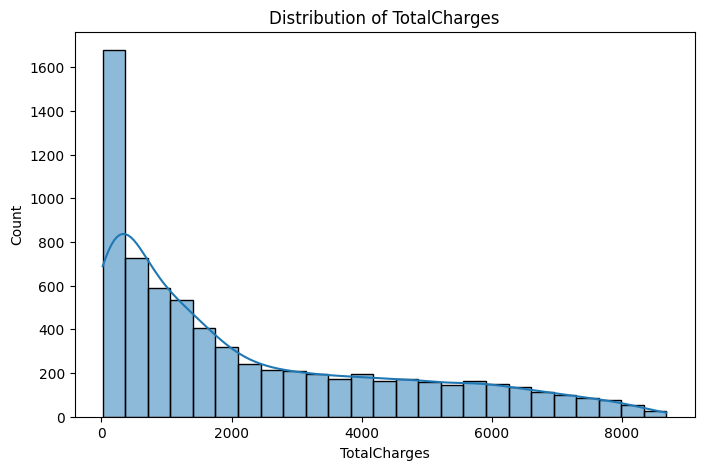

In [14]:
for i in num:
  plt.figure(figsize=(8,5))
  sns.histplot(df[i],kde=True)
  plt.title(f'Distribution of {i}')
  plt.show()

In [15]:
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

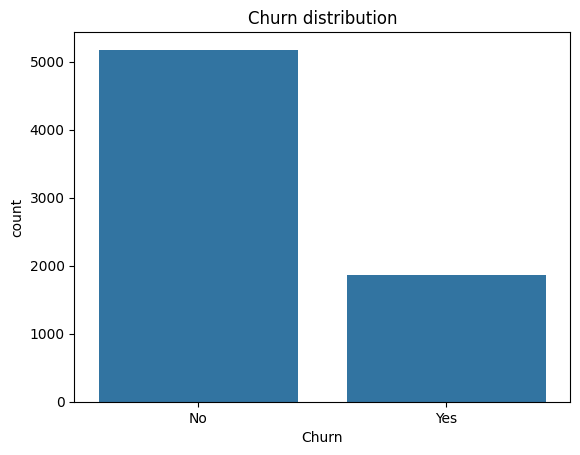

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [16]:
sns.countplot(data=df,x="Churn")
plt.title("Churn distribution")
plt.show()
print(df["Churn"].value_counts(normalize=True)*100)

<function matplotlib.pyplot.show(close=None, block=None)>

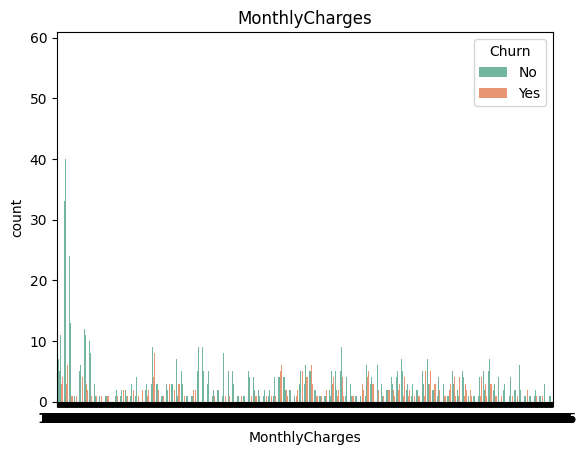

In [17]:
from matplotlib import colors
sns.countplot(data=df,x="MonthlyCharges",hue="Churn",palette="Set2")
plt.title("MonthlyCharges")
plt.show

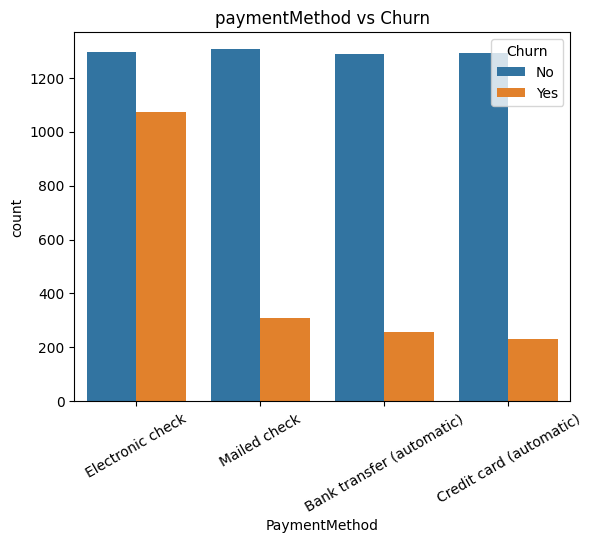

In [18]:
sns.countplot(data=df,x="PaymentMethod",hue="Churn",)
plt.xticks(rotation=30)
plt.title("paymentMethod vs Churn")
plt.show()

In [19]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [20]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_log
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3.429137
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,7.544597
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4.692723
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7.518471
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5.028148


In [21]:
df.drop(columns=["customerID"],inplace=True)

In [22]:
def tenure_group(tenure):
  if tenure<=12:
    return "new"
  elif tenure<=36:
    return "mid"
  else:
    return "loyal"
df["tenure_group"]=df["tenure"].apply(tenure_group)
df["tenure_group"].value_counts()

,count
tenure_group,
loyal,3001
new,2186
mid,1856


In [23]:
cate_col=df.select_dtypes(include=("object"))
cate_col

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,tenure_group
0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,new
1,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,mid
2,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,new
3,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,loyal
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No,mid
7039,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No,loyal
7040,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No,new
7041,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,new


In [24]:
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
   df[col] = df[col].map({'Yes': 1, 'No': 0})

In [25]:
cate_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   gender            7043 non-null   object
 1   Partner           7043 non-null   object
 2   Dependents        7043 non-null   object
 3   PhoneService      7043 non-null   object
 4   MultipleLines     7043 non-null   object
 5   InternetService   7043 non-null   object
 6   OnlineSecurity    7043 non-null   object
 7   OnlineBackup      7043 non-null   object
 8   DeviceProtection  7043 non-null   object
 9   TechSupport       7043 non-null   object
 10  StreamingTV       7043 non-null   object
 11  StreamingMovies   7043 non-null   object
 12  Contract          7043 non-null   object
 13  PaperlessBilling  7043 non-null   object
 14  PaymentMethod     7043 non-null   object
 15  Churn             7043 non-null   object
 16  tenure_group      7043 non-null   object
dtypes: object(17)


In [26]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["gender"]=le.fit_transform(df["gender"])
df["Partner"]=le.fit_transform(df["Partner"])
df["Dependents"]=le.fit_transform(df["Dependents"])
df["PhoneService"]=le.fit_transform(df["PhoneService"])
df["MultipleLines"]=le.fit_transform(df["MultipleLines"])
df["InternetService"]=le.fit_transform(df["InternetService"])
df["OnlineBackup"]=le.fit_transform(df["OnlineBackup"])
df["DeviceProtection"]=le.fit_transform(df["DeviceProtection"])
df["TechSupport"]=le.fit_transform(df["TechSupport"])
df["StreamingTV"]=le.fit_transform(df["StreamingTV"])
df["StreamingMovies"]=le.fit_transform(df["StreamingMovies"])
df["Contract"]=le.fit_transform(df["Contract"])
df["PaperlessBilling"]=le.fit_transform(df["PaperlessBilling"])
df["PaymentMethod"]=le.fit_transform(df["PaymentMethod"])
df["Churn"]=le.fit_transform(df["Churn"])
df["tenure_group"]=le.fit_transform(df["tenure_group"])
df["OnlineSecurity"]=le.fit_transform(df["OnlineSecurity"])

In [27]:
#x

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit_transform(num)

array([[-0.43991649, -1.27744458, -1.16032292, -0.99419409],
       [-0.43991649,  0.06632742, -0.25962894, -0.17373982],
       [-0.43991649, -1.23672422, -0.36266036, -0.95964911],
       ...,
       [-0.43991649, -0.87024095, -1.1686319 , -0.85451414],
       [ 2.27315869, -1.15528349,  0.32033821, -0.87209546],
       [-0.43991649,  1.36937906,  1.35896134,  2.01234407]])

In [29]:
x=df.drop("Churn",axis=1)
y=df["Churn"]

Churn
0    5174
1    1869
Name: count, dtype: int64
---
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


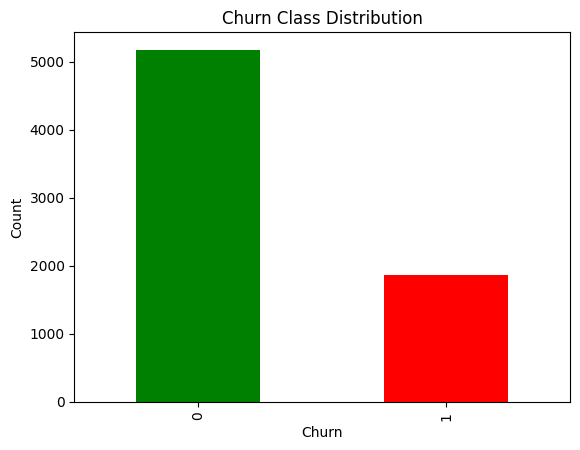

In [30]:
print(df['Churn'].value_counts())
print("---")
print(df['Churn'].value_counts(normalize=True) * 100)

df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [31]:
# Check how many NaN
print(x.isnull().sum()[x.isnull().sum() > 0])

# Fill NaN
x['TotalCharges'].fillna(x['TotalCharges'].median(), inplace=True)
x['TotalCharges_log'].fillna(x['TotalCharges_log'].median(), inplace=True)

# Confirm fixed
print(x.isnull().sum().sum(), "NaN remaining")

TotalCharges        11
TotalCharges_log    11
dtype: int64
0 NaN remaining


/tmp/ipykernel_11052/4066479708.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['TotalCharges'].fillna(x['TotalCharges'].median(), inplace=True)
/tmp/ipykernel_11052/4066479708.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [32]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_res,y_res=smote.fit_resample(x,y)
print("After SMOTE:", y_res.value_counts())

After SMOTE: Churn
0    5174
1    5174
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.2,random_state=42)

In [34]:
x_train.shape

(8278, 21)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)
print("Accuarcy",accuracy_score(y_test,y_pred_lr))
print("precision",precision_score(y_test,y_pred_lr))
print("recall",recall_score(y_test,y_pred_lr))
print("f1_score",f1_score(y_test,y_pred_lr))
print("confusion_matrix",confusion_matrix(y_test,y_pred_lr))

Accuarcy 0.8091787439613527
precision 0.7924865831842576
recall 0.8446139180171592
f1_score 0.8177203507152746
confusion_matrix [[789 232]
 [163 886]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


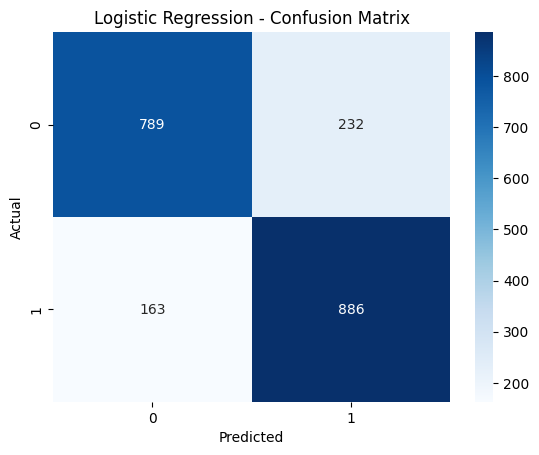

In [36]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("recall",recall_score(y_test, y_pred_rf))
print("precision",precision_score(y_test, y_pred_rf))
print("f1_score",f1_score(y_test, y_pred_rf))
print("confusion_matrix",confusion_matrix(y_test,y_pred_rf))
print("Classification report",classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8613526570048309
recall 0.8636796949475691
precision 0.8628571428571429
f1_score 0.8632682229633158
confusion_matrix [[877 144]
 [143 906]]
Classification report               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1021
           1       0.86      0.86      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.86      0.86      0.86      2070
weighted avg       0.86      0.86      0.86      2070

ROC-AUC: 0.8613207485511597


In [38]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42,)
xgb.fit(x_train,y_train)
y_pred_xgb=xgb.predict(x_test)

print("=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("classification repirt",classification_report(y_test, y_pred_xgb))
print("ROC-AUC:",roc_auc_score(y_test, y_pred_xgb))
print("precison",precision_score(y_test,y_pred_xgb))
print("recall",recall_score(y_test,y_pred_xgb))
print("f1_score",f1_score(y_test,y_pred_xgb))

=== XGBoost ===
Accuracy: 0.8541062801932368
classification repirt               precision    recall  f1-score   support

           0       0.86      0.85      0.85      1021
           1       0.85      0.86      0.86      1049

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070

ROC-AUC: 0.8540011521630133
precison 0.8520263901979265
recall 0.8617731172545281
f1_score 0.8568720379146919


In [39]:
results = {
      'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
          'Accuracy': [
                  accuracy_score(y_test, y_pred_lr),
                  accuracy_score(y_test, y_pred_rf),
                  accuracy_score(y_test, y_pred_xgb)
                                      ],
          'ROC-AUC': [
                  roc_auc_score(y_test, y_pred_lr),
                  roc_auc_score(y_test, y_pred_rf),
                  roc_auc_score(y_test, y_pred_xgb)
                                                                      ]
}
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.809179  0.808693
1        Random Forest  0.861353  0.861321
2              XGBoost  0.854106  0.854001


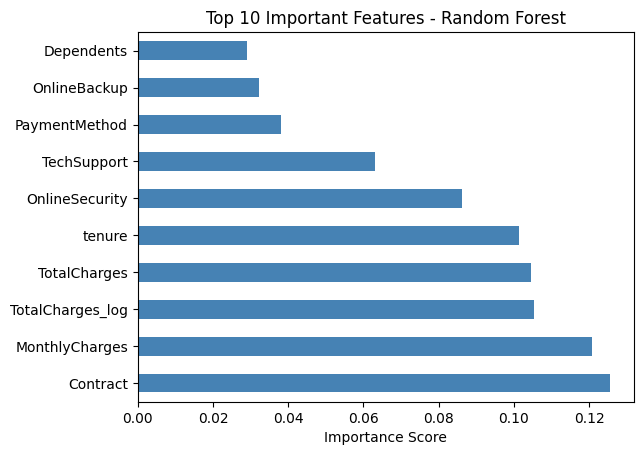

In [40]:
feat_imp = pd.Series(rf.feature_importances_, index=x.columns)
feat_imp.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.show()

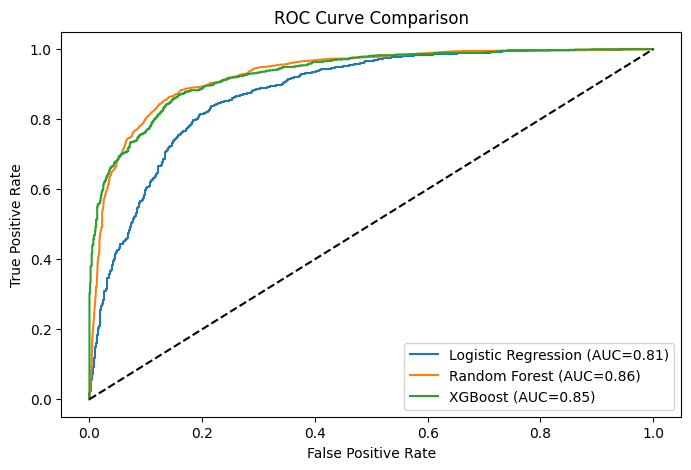

In [41]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8,5))

for model, pred, name in [
    (lr, y_pred_lr, 'Logistic Regression'),
    (rf, y_pred_rf, 'Random Forest'),
    (xgb, y_pred_xgb, 'XGBoost')
            ]:
                fpr, tpr, _ = roc_curve(y_test, model.predict_proba(x_test)[:,1])
                ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, pred):.2f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

In [42]:
import joblib

joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved!")

Model saved!


In [43]:
churned=df[df["Churn"]==1].copy()
print(churned.shape)

(1869, 22)


In [56]:
seg_feature=['tenure', 'MonthlyCharges', 'TotalCharges']
churn_seg=churned[seg_feature].copy()
churn_seg.head()

,tenure,MonthlyCharges,TotalCharges
2,2,53.85,108.15
4,2,70.70,151.65
5,8,99.65,820.50
8,28,104.80,3046.05
13,49,103.70,5036.30


In [57]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
churned_scale=scaler.fit_transform(churn_seg)
print(churn_seg.shape)

(1869, 3)


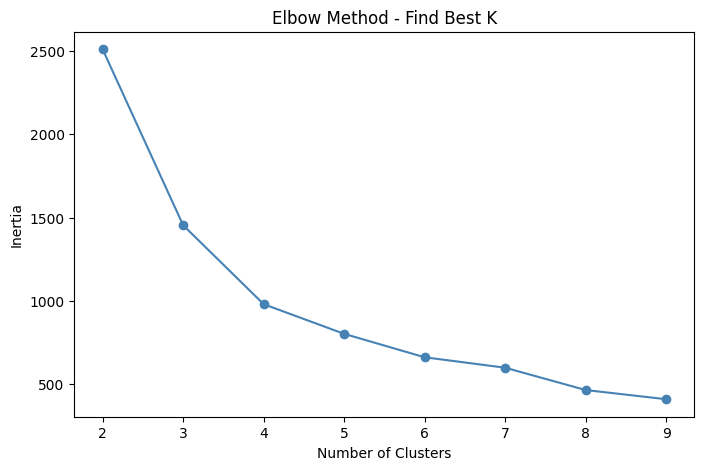

In [70]:
from sklearn.cluster import KMeans
inertia=[]
k_range=range(2,10)
for i in k_range:
  km=KMeans(n_clusters=i,random_state=42)
  km.fit(churned_scale)
  inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - Find Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [71]:
km_final=KMeans(n_clusters=5,random_state=42)
churned["Segment"]=km_final.fit_predict(churned_scale)
print(churned['Segment'].value_counts())

Segment
3    776
0    423
2    335
1    239
4     96
Name: count, dtype: int64


In [72]:
seg_summary = churned.groupby('Segment')[seg_feature].mean()
print(seg_summary)

            tenure  MonthlyCharges  TotalCharges
Segment                                         
0         5.260047       37.838771    200.682979
1        56.410042       99.838703   5645.815690
2        27.650746       91.329552   2505.895373
3         5.886598       82.015786    490.469974
4        42.343750       52.332812   2173.004167


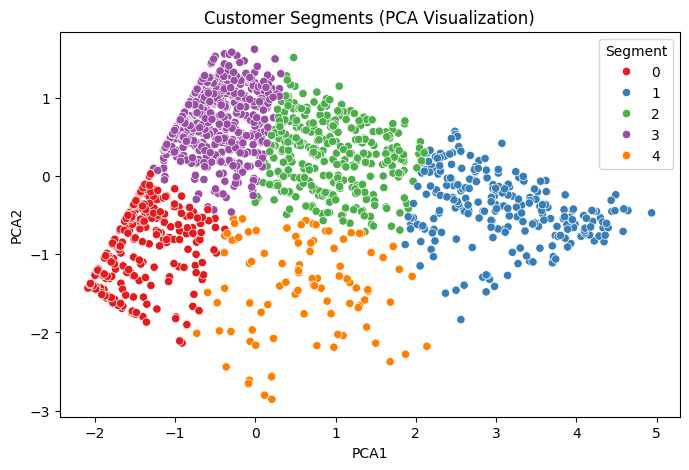

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(churned_scale)

churned['PCA1'] = pca_result[:, 0]
churned['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8,5))
sns.scatterplot(data=churned, x='PCA1', y='PCA2',
                hue='Segment', palette='Set1')
plt.title('Customer Segments (PCA Visualization)')
plt.show()

In [74]:
segment_names = {
      0: 'New Low-Value Customers',
          1: 'Loyal Premium Customers',
              2: 'Mid-Tenure High Spenders',
                  3: 'New Price-Shocked Customers',
                      4: 'Mid-Tenure Low Spenders'
                      }

churned['Segment_Name'] = churned['Segment'].map(segment_names)
churned['Segment_Name'].value_counts()



,count
Segment_Name,
New Price-Shocked Customers,776
New Low-Value Customers,423
Mid-Tenure High Spenders,335
Loyal Premium Customers,239
Mid-Tenure Low Spenders,96


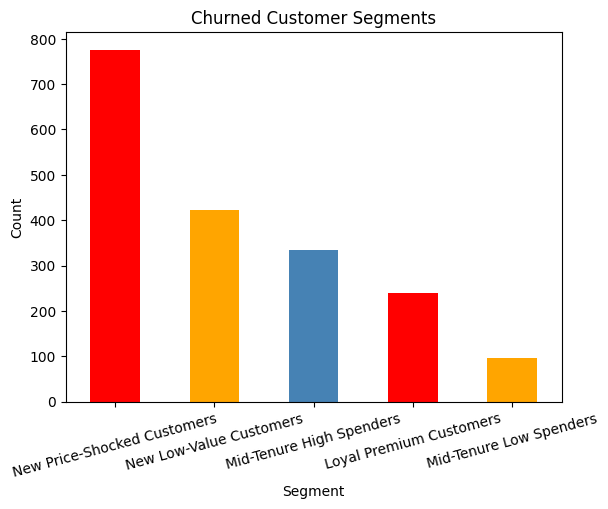

In [75]:
churned['Segment_Name'].value_counts().plot(
      kind='bar', color=['red','orange','steelblue'])
plt.title('Churned Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()


In [69]:
import joblib

churned.to_csv('churned_segmented.csv', index=False)
joblib.dump(km_final, 'kmeans_model.pkl')
joblib.dump(churn_seg, 'churn_seg.pkl')
print("Segmentation saved!")

Segmentation saved!


In [76]:
def get_recommendation(segment_name):
    recommendations = {
        'New Low-Value Customers': {
            'Risk': 'Medium',
            'Strategy': 'Onboarding Support',
            'Offer': 'Provide free onboarding assistance and offer a 10% discount on first 3 months',
            'Action': 'Assign dedicated support agent for first 30 days'
        },
        'Loyal Premium Customers': {
            'Risk': 'Very High',
            'Strategy': 'Loyalty Reward',
            'Offer': 'Offer exclusive VIP loyalty program with 20% discount and priority support',
            'Action': 'Personal call from retention team within 24 hours'
        },
        'Mid-Tenure High Spenders': {
            'Risk': 'High',
            'Strategy': 'Value Enhancement',
            'Offer': 'Upgrade to annual contract with 15% discount and free add-on services',
            'Action': 'Send personalized email with tailored upgrade offer'
        },
        'New Price-Shocked Customers': {
            'Risk': 'Very High',
            'Strategy': 'Price Reduction',
            'Offer': 'Immediately offer 25% price reduction or downgrade to affordable plan',
            'Action': 'Trigger automated discount coupon within 48 hours of signup'
        },
        'Mid-Tenure Low Spenders': {
            'Risk': 'Medium',
            'Strategy': 'Upsell + Retain',
            'Offer': 'Offer bundled services upgrade at same price point',
            'Action': 'Send monthly value report showing benefits they are missing'
        }
    }
    return recommendations.get(segment_name, 'No recommendation available')

In [77]:
churned['Recommendation'] = churned['Segment_Name'].apply(get_recommendation)
churned[['Segment_Name', 'Recommendation']].head(10)

,Segment_Name,Recommendation
2,New Low-Value Customers,"{'Risk': 'Medium', 'Strategy': 'Onboarding Sup..."
4,New Price-Shocked Customers,"{'Risk': 'Very High', 'Strategy': 'Price Reduc..."
5,New Price-Shocked Customers,"{'Risk': 'Very High', 'Strategy': 'Price Reduc..."
8,Mid-Tenure High Spenders,"{'Risk': 'High', 'Strategy': 'Value Enhancemen..."
13,Loyal Premium Customers,"{'Risk': 'Very High', 'Strategy': 'Loyalty Rew..."
18,New Low-Value Customers,"{'Risk': 'Medium', 'Strategy': 'Onboarding Sup..."
20,New Low-Value Customers,"{'Risk': 'Medium', 'Strategy': 'Onboarding Sup..."
22,New Low-Value Customers,"{'Risk': 'Medium', 'Strategy': 'Onboarding Sup..."
26,Loyal Premium Customers,"{'Risk': 'Very High', 'Strategy': 'Loyalty Rew..."
27,New Low-Value Customers,"{'Risk': 'Medium', 'Strategy': 'Onboarding Sup..."


In [78]:
for seg in churned['Segment_Name'].unique():
    rec = get_recommendation(seg)
    print(f"\n{'='*50}")
    print(f"Segment   : {seg}")
    print(f"Risk Level: {rec['Risk']}")
    print(f"Strategy  : {rec['Strategy']}")
    print(f"Offer     : {rec['Offer']}")
    print(f"Action    : {rec['Action']}")


Segment   : New Low-Value Customers
Risk Level: Medium
Strategy  : Onboarding Support
Offer     : Provide free onboarding assistance and offer a 10% discount on first 3 months
Action    : Assign dedicated support agent for first 30 days

Segment   : New Price-Shocked Customers
Risk Level: Very High
Strategy  : Price Reduction
Offer     : Immediately offer 25% price reduction or downgrade to affordable plan
Action    : Trigger automated discount coupon within 48 hours of signup

Segment   : Mid-Tenure High Spenders
Risk Level: High
Strategy  : Value Enhancement
Offer     : Upgrade to annual contract with 15% discount and free add-on services
Action    : Send personalized email with tailored upgrade offer

Segment   : Loyal Premium Customers
Risk Level: Very High
Strategy  : Loyalty Reward
Offer     : Offer exclusive VIP loyalty program with 20% discount and priority support
Action    : Personal call from retention team within 24 hours

Segment   : Mid-Tenure Low Spenders
Risk Level: Me

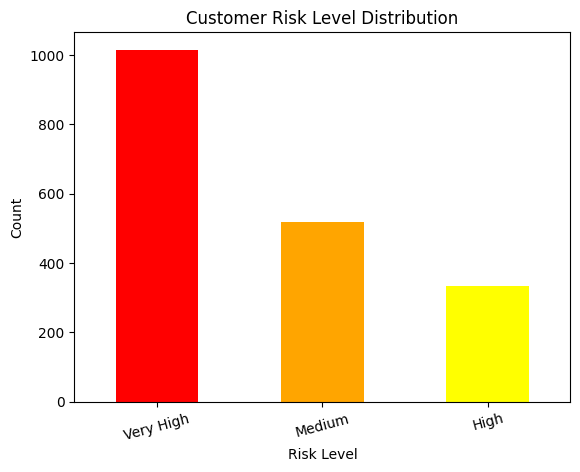

In [79]:
risk_map = {
    'New Low-Value Customers': 'Medium',
    'Loyal Premium Customers': 'Very High',
    'Mid-Tenure High Spenders': 'High',
    'New Price-Shocked Customers': 'Very High',
    'Mid-Tenure Low Spenders': 'Medium'
}

churned['Risk_Level'] = churned['Segment_Name'].map(risk_map)

churned['Risk_Level'].value_counts().plot(
    kind='bar',
    color=['red', 'orange', 'yellow'])
plt.title('Customer Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

In [80]:
churned.to_csv('final_recommendations.csv', index=False)
print("✅ Recommendations saved!")
print(f"Total customers with recommendations: {len(churned)}")
print("\nSegment breakdown:")
print(churned['Segment_Name'].value_counts())

✅ Recommendations saved!
Total customers with recommendations: 1869

Segment breakdown:
Segment_Name
New Price-Shocked Customers    776
New Low-Value Customers        423
Mid-Tenure High Spenders       335
Loyal Premium Customers        239
Mid-Tenure Low Spenders         96
Name: count, dtype: int64
